In [1]:
import stim
import numpy as np

from spiderwarp.csscode import CSSCode
from spiderwarp.utils import load_state_prep_circuit
from spiderwarp.stim_utils import steane_se_from_stim_state_prep, get_num_measurements, perfect_state_from_code
from spiderwarp.path_cover import CoveredZXGraph
from spiderwarp.path_cover_metrics import metric_spacetime_volume_exact, metric_hardware_qubits_exact, metric_num_paths
from spiderwarp.qubit_reuse import build_circuit_dag, apply_logical_qubit_merge_and_compress, dag_to_circuit, inject_qubit_reuse, VolumeOptimizingReuseStrategy, AggressiveDepthAwareStrategy


%load_ext autoreload
%autoreload 2

In [2]:
code_dir, code_name, circ_dir, circ_path = "misc", "32_20_4", "misc", "zero_32_20_4"
code = CSSCode.load_code(code_dir, code_name)

perfect_state = perfect_state_from_code(code, "X")

test = perfect_state.copy()
test.append("MX", range(code.n))
print(test.compile_sampler().sample(10)[:,-code.n:] @ code.H_x.T % 2)

[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


Number of ancilla qubits necessary: 34


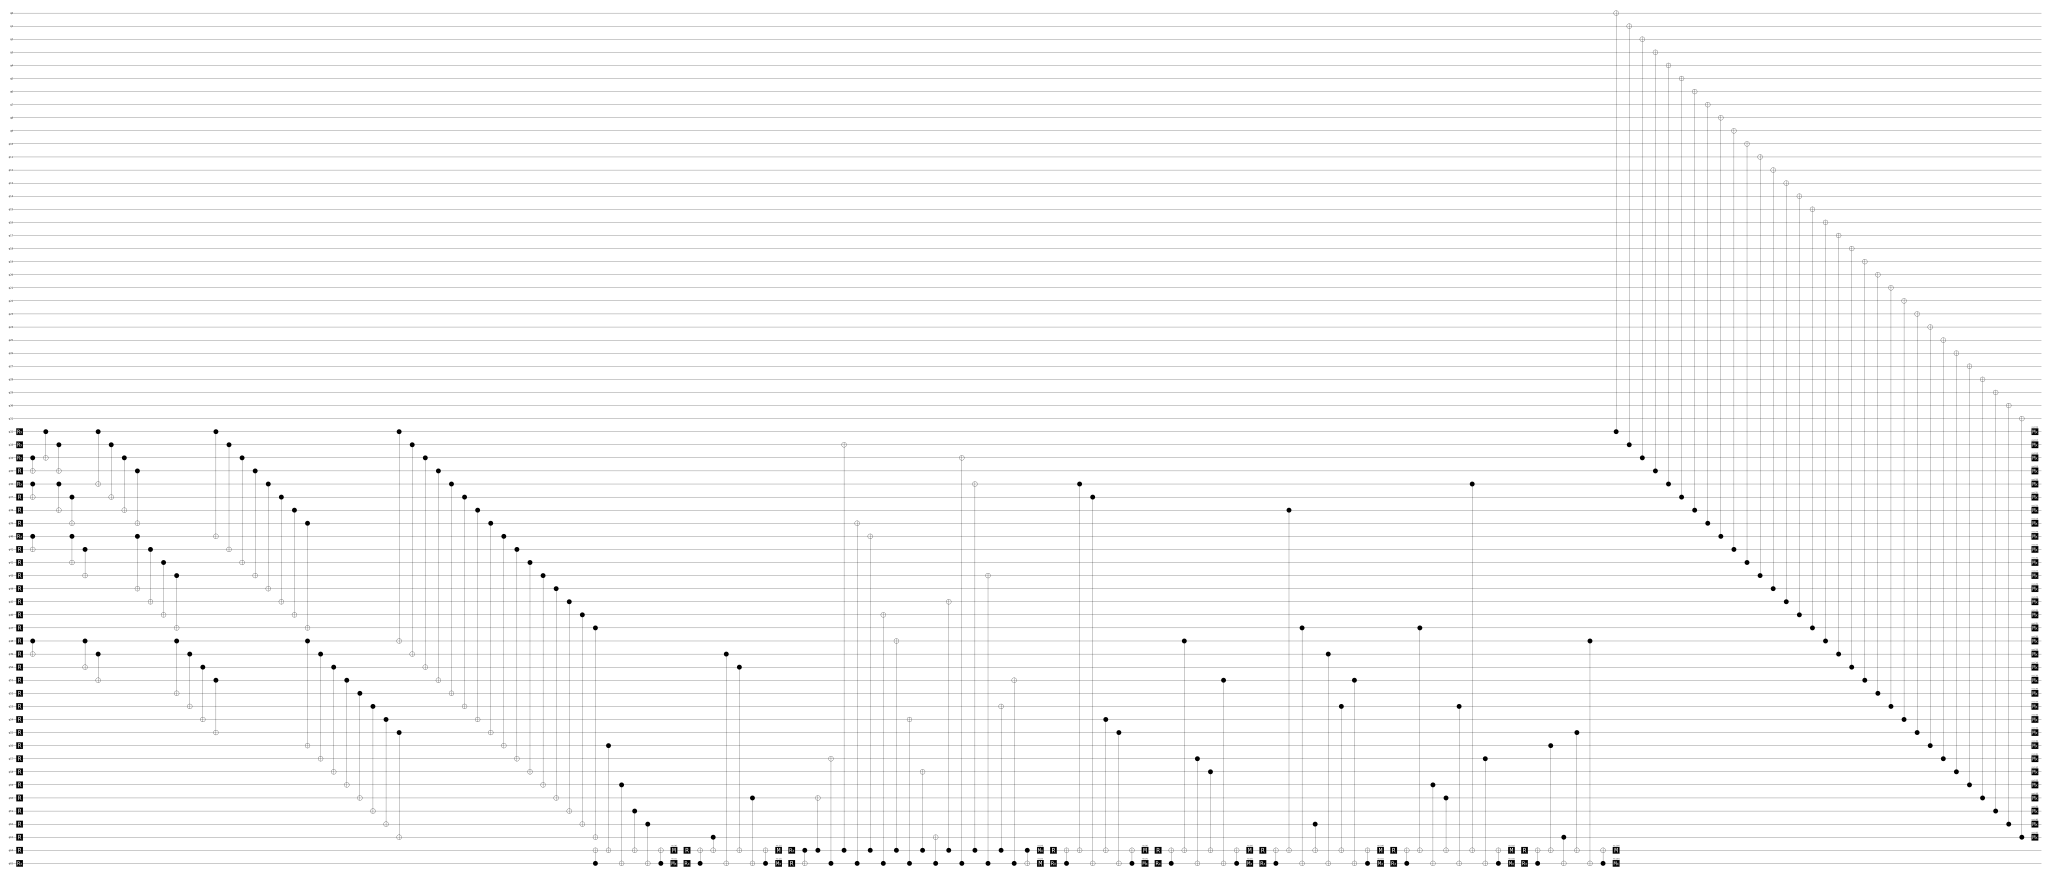

In [3]:
circuit = load_state_prep_circuit(circ_dir, circ_path)
se = steane_se_from_stim_state_prep(circuit, se_basis="Z", n=code.n)

print("Number of ancilla qubits necessary:", se.num_qubits - code.n)
se.diagram('timeline-svg')

In [4]:
samples = (perfect_state + se).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]
print(samples[:,:-code.n].astype(int))
print(samples[:,-code.n:] @ code.H_z.T % 2)

[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]]
[[0 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]]


Number of ancilla qubits necessary: 44
Mapping of new measurements to old measurements: {0: 28, 1: 21, 2: 36, 3: 25, 4: 16, 5: 3, 6: 23, 7: 45, 8: 40, 9: 0, 10: 1, 11: 39, 12: 17, 13: 30, 14: 2, 15: 34, 16: 46, 17: 24, 18: 33, 19: 47, 20: 42, 21: 32, 22: 18, 23: 43, 24: 44, 25: 14, 26: 15, 27: 27, 28: 29, 29: 5, 30: 6, 31: 38, 32: 7, 33: 8, 34: 9, 35: 35, 36: 20, 37: 4, 38: 10, 39: 11, 40: 37, 41: 41, 42: 12, 43: 13}


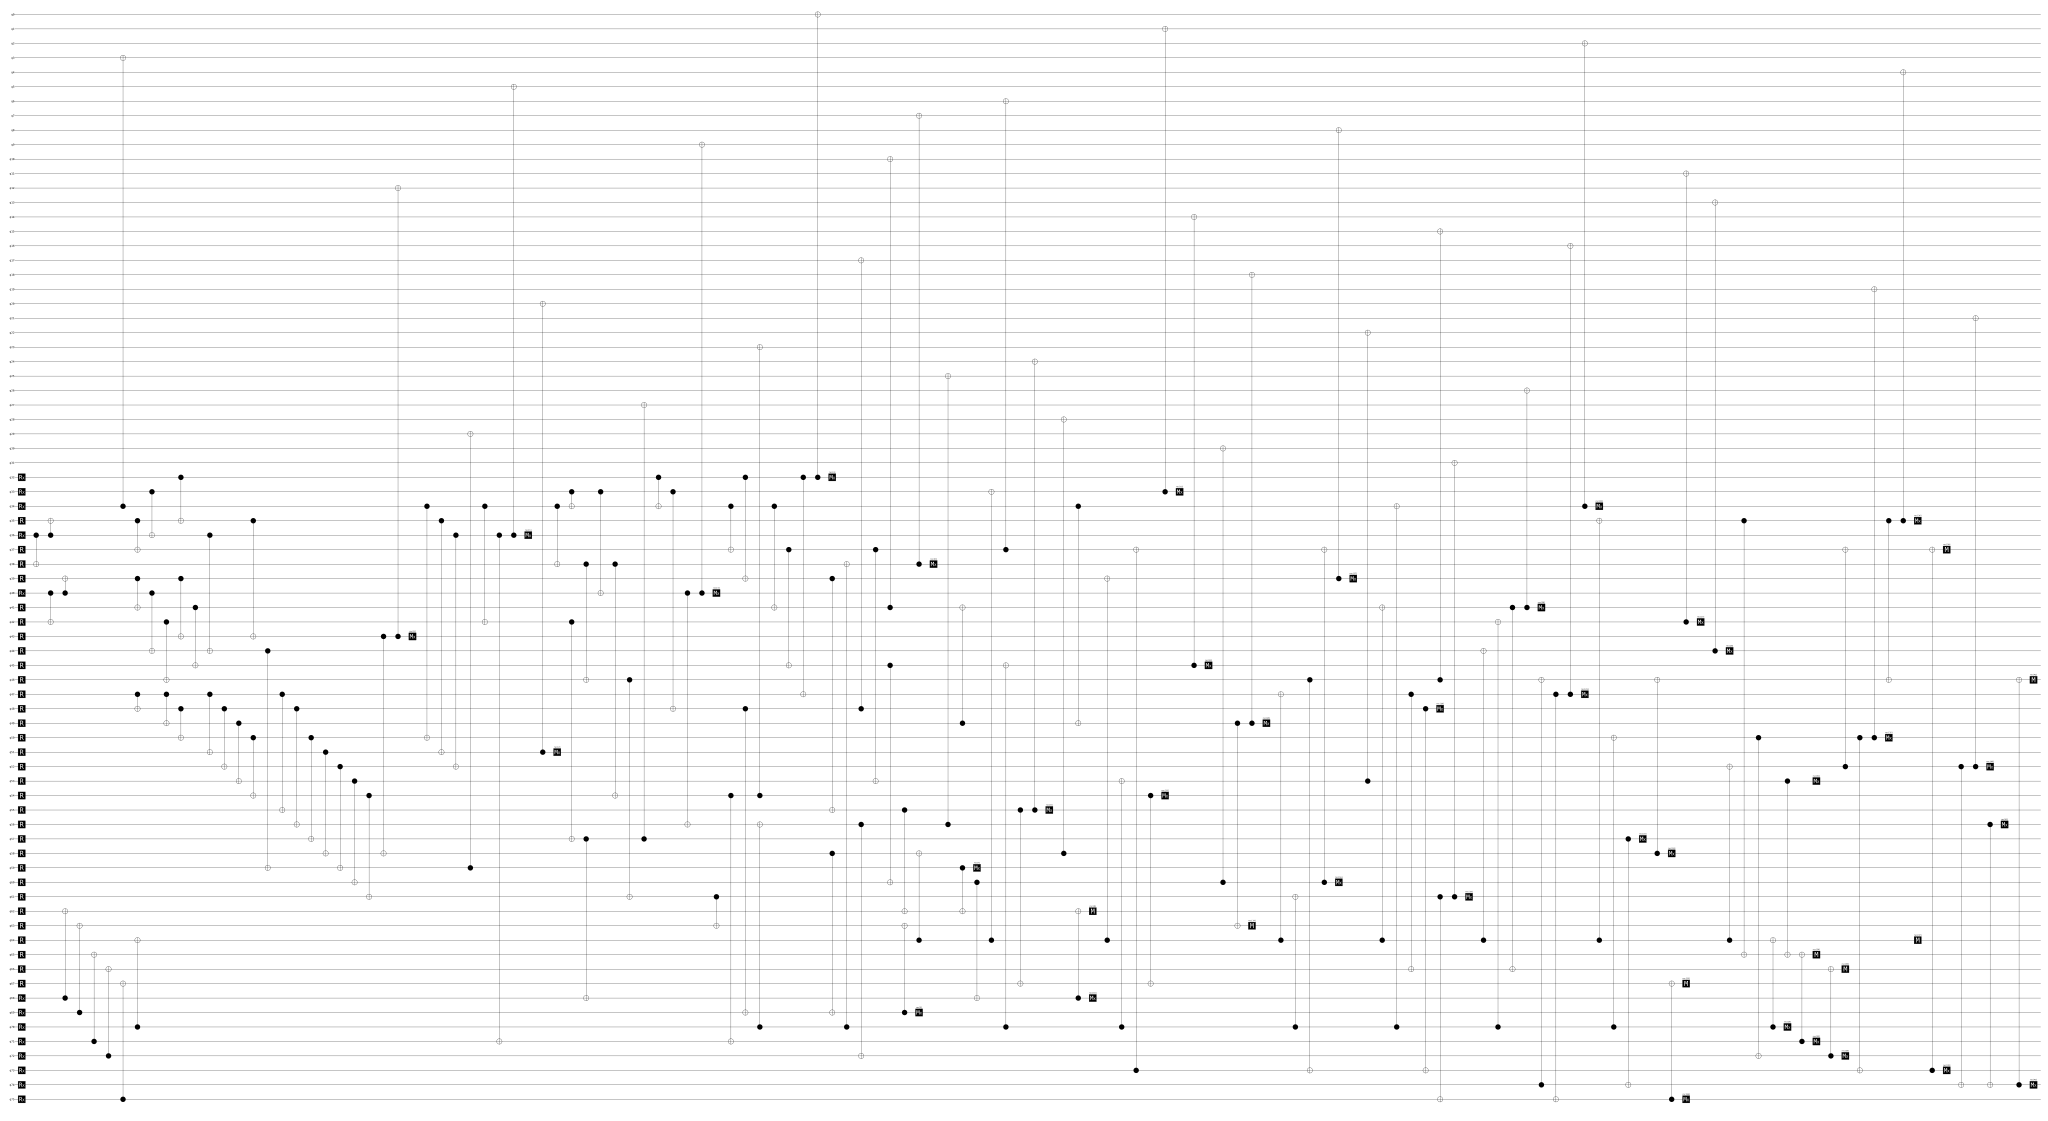

In [5]:
covered = CoveredZXGraph.from_stim(se)
covered.basic_FE_rewrites()
optimised = covered.greedy_best_first_boundary_bends(
    cost_func=metric_hardware_qubits_exact(AggressiveDepthAwareStrategy),
    max_evaluations=10
)
new_circuit, measurement_map = optimised.extract_circuit_with_measurement_map()

print("Number of ancilla qubits necessary:", new_circuit.num_qubits - code.n)
print("Mapping of new measurements to old measurements:", measurement_map)
new_circuit.diagram('timeline-svg')

In [6]:
samples = (perfect_state + new_circuit).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]

num_measurements = get_num_measurements(se)
flag_indices = [k for k, v in measurement_map.items() if v < num_measurements - code.n]
flags = samples[:,flag_indices].astype(int)

print("Flags:", flags, sep="\n", end="\n\n")

syndrome_indices = {k: v - (num_measurements - code.n) for k, v in measurement_map.items() if v >= num_measurements - code.n}
effective_H = code.H_z[:,list(syndrome_indices.values())]
raw_syndrome_measurements = samples[:,list(syndrome_indices.keys())]
syndromes = raw_syndrome_measurements @ effective_H.T % 2

print("Syndromes:", syndromes, sep="\n")

Flags:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

Syndromes:
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


Number of ancilla qubits necessary: 27
Mapping of new measurements to old measurements: {0: 21, 1: 28, 2: 36, 3: 25, 4: 3, 5: 23, 6: 17, 7: 16, 8: 24, 9: 30, 10: 2, 11: 34, 12: 29, 13: 18, 14: 38, 15: 27, 16: 6, 17: 7, 18: 5, 19: 4, 20: 33, 21: 44, 22: 20, 23: 42, 24: 8, 25: 9, 26: 35, 27: 45, 28: 43, 29: 0, 30: 1, 31: 46, 32: 10, 33: 11, 34: 37, 35: 41, 36: 12, 37: 13, 38: 40, 39: 39, 40: 47, 41: 32, 42: 14, 43: 15}


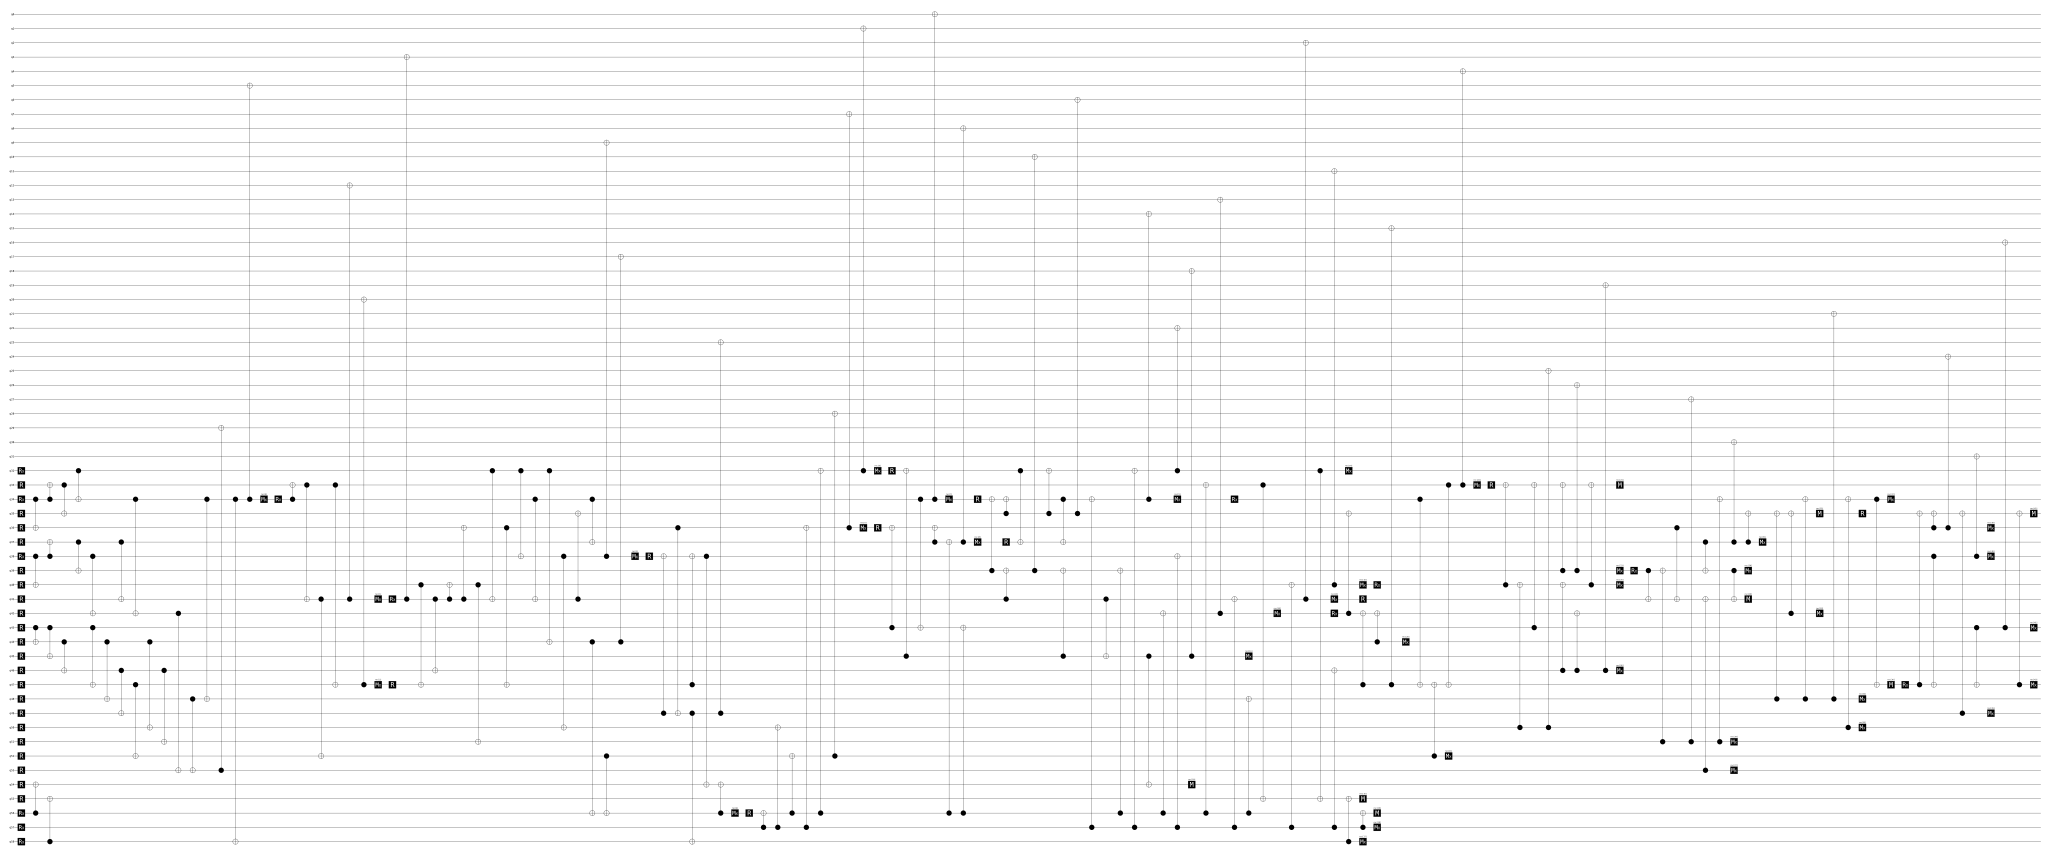

In [7]:
dag = build_circuit_dag(optimised)

mod_dag, logical_to_physical, total_hw = inject_qubit_reuse(dag, code.n, AggressiveDepthAwareStrategy())
compressed_dag = apply_logical_qubit_merge_and_compress(mod_dag, code.n)
final_circ, final_meas_map = dag_to_circuit(compressed_dag)

print("Number of ancilla qubits necessary:", final_circ.num_qubits - code.n)
print("Mapping of new measurements to old measurements:", final_meas_map)
final_circ.diagram('timeline-svg')

In [10]:
samples = (perfect_state + final_circ).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]

num_measurements = get_num_measurements(se)
flag_indices = [k for k, v in final_meas_map.items() if v < num_measurements - code.n]
flags = samples[:,flag_indices].astype(int)

print("Flags:", flags, sep="\n", end="\n\n")

syndrome_indices = {k: v - (num_measurements - code.n) for k, v in final_meas_map.items() if v >= num_measurements - code.n}
effective_H = code.H_z[:,list(syndrome_indices.values())]
raw_syndrome_measurements = samples[:,list(syndrome_indices.keys())]
syndromes = raw_syndrome_measurements @ effective_H.T % 2

print("Syndromes:", syndromes, sep="\n")

Flags:
[[0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

Syndromes:
[[0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 0]
 [0 1 0 0 0 0]
 [0 0 0 0 0 0]]
